In [1]:
from src.dataset import load_dataset
from sklearn.model_selection import train_test_split
from polynomial_regression import PolynomialRegression
from probabilistic_rf_scoring import get_regression_score
from pdf import choose_pdf, plot_curves
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import joblib

In [2]:
TRAIN_SPLIT=0.85
TEST_SPLIT=0.15
TRAIN_PATH_X = "../../../data/processed/train/train.csv"
TEST_PATH = "../../../data/processed/test/test.csv"
RESIDUI_PATH = f"../../../output/polynomial_regression/residui_taget_train{TRAIN_SPLIT}_test{TEST_SPLIT}"
OUTPUT_PATH="../../../output/polynomial_regression/model_target/"
MODEL_PATH="polynomial_regression_model_target.pkl"
RESIDUI_CSV="/residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
DEGREE = {1,2,3}


Degree  1
MAE: 0.1856531241041323
MSE: 0.06616427338499542
RMSE: 0.25722416951949795
R²: 0.9996718700678418


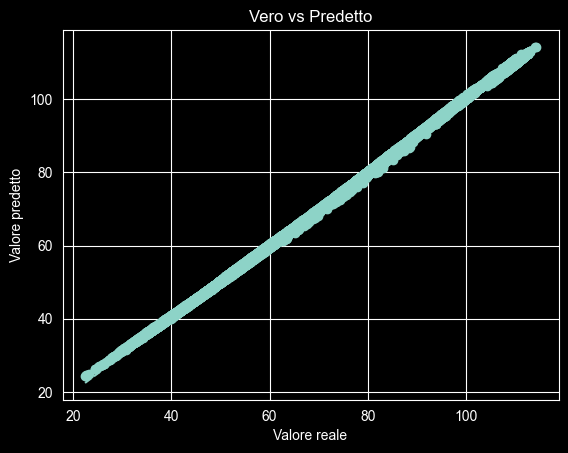


Degree  2
MAE: 0.02103265161047206
MSE: 0.001339424478432166
RMSE: 0.03659814856563329
R²: 0.9999933573628069


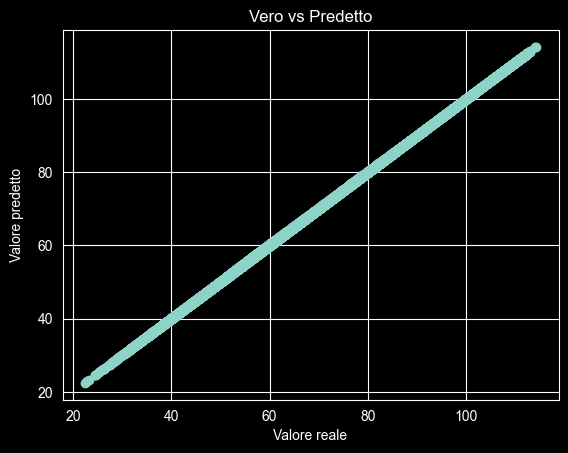


Degree  3
MAE: 0.017007832111308473
MSE: 0.0008050629593949471
RMSE: 0.028373631410077687
R²: 0.9999960074336083


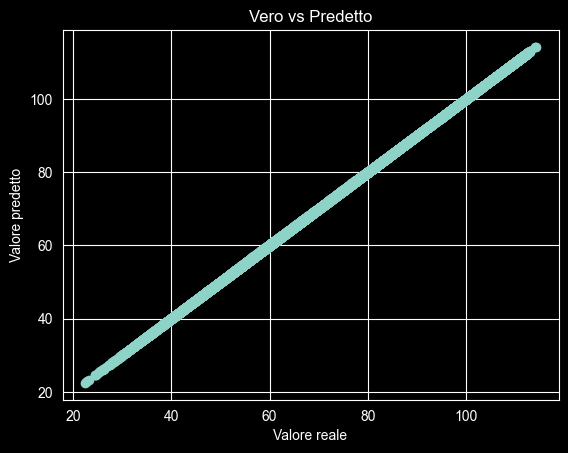

In [3]:
train_data = pd.read_csv(TRAIN_PATH_X)
train_df, test_df = train_test_split(
    train_data,
    test_size=TEST_SPLIT,
    random_state=42,
    shuffle=True
)
drop_cols = [TARGET_COL]
X_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[X_cols].values
y_train = train_df[TARGET_COL].values

X_test = test_df[X_cols].values
y_test = test_df[TARGET_COL].values

for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [4]:
model = PolynomialRegression(degree=3)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [5]:
if os.path.exists(not RESIDUI_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=RESIDUI_PATH)

In [6]:
residui = load_dataset(RESIDUI_PATH + RESIDUI_CSV)

test_row = test_df.iloc[2342]
test_x = test_row[X_cols].to_frame().T
test_y_true =(test_row["trq_measured"] / test_row["trq_target"] - 1) * 100
target_pred = model.predict(test_x)[0]
trq_margin_pred = (test_row["trq_measured"]/ target_pred - 1) * 100
rows = []
for m in range(ITERATIONS):
    residual = float(residui.sample(n=1)["residual"].iloc[0])
    rows.append({"trq_target_probability": target_pred + residual})

distribution = pd.DataFrame(rows)
distribution["trq_margin"] = (test_row["trq_measured"] / distribution["trq_target_probability"] - 1) * 100
distribution.head()

,trq_target_probability,trq_margin
0,93.390924,-11.768728
1,93.388954,-11.766867
2,93.389752,-11.767621
3,93.402493,-11.779657
4,93.411530,-11.788191


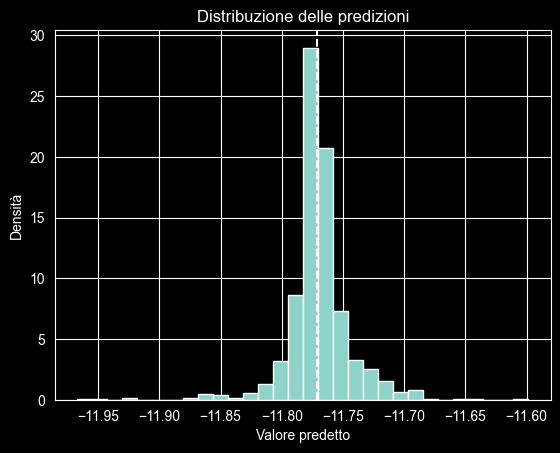

In [7]:
plt.figure()
plt.hist(distribution["trq_margin"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

-11.775189183466628
-11.770328008788015


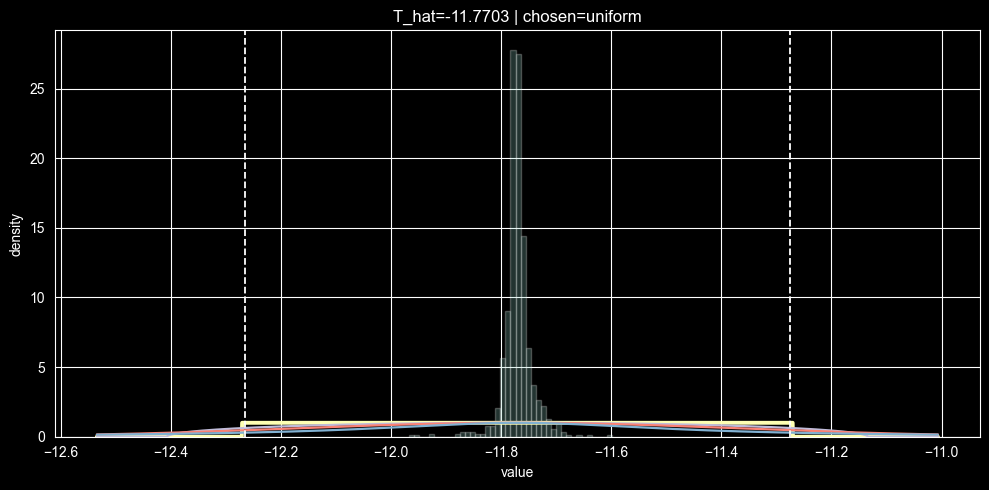

PDF scelta: uniform
Score: 0.9999899999999938


In [12]:
trq_margin_mean=np.mean(distribution["trq_margin"])
print(test_y_true)
print(trq_margin_mean)
pdf_type, pdf_args,_ = choose_pdf(distribution["trq_margin"], trq_margin_mean)
score = get_regression_score(pdf_type, pdf_args,test_y_true)
plot_curves(distribution["trq_margin"], trq_margin_mean, pdf_type)

print("PDF scelta:", pdf_type)
print("Score:", score)
